Importing Libraries and Data

In [1]:
import zipfile ,os
import re, unicodedata
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import TextVectorization
import nltk
nltk.download ('stopwords')
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

with zipfile.ZipFile("archive (1).zip","r") as z:
  z.extractall("data")
  

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arjb0\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Data Exploration

01 Harry Potter and the Sorcerers Stone.txt
02 Harry Potter and the Chamber of Secrets.txt
03 Harry Potter and the Prisoner of Azkaban.txt
04 Harry Potter and the Goblet of Fire.txt
05 Harry Potter and the Order of the Phoenix.txt
06 Harry Potter and the Half-Blood Prince.txt
07 Harry Potter and the Deathly Hallows.txt
Total characters loaded :2658028
M r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in anything strange or mysterious, because they just didn’t hold with such nonsense.

Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amoun
tolal char:2658028
total words :466050
unique words:38955
average words per sentences:12.69
[('the', 20332), ('to', 11126), ('and', 10807), ('of'

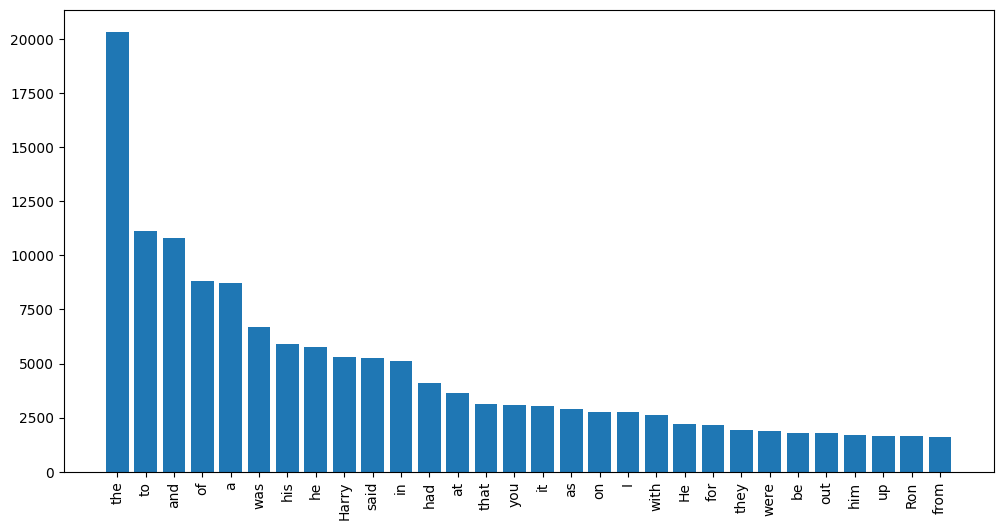

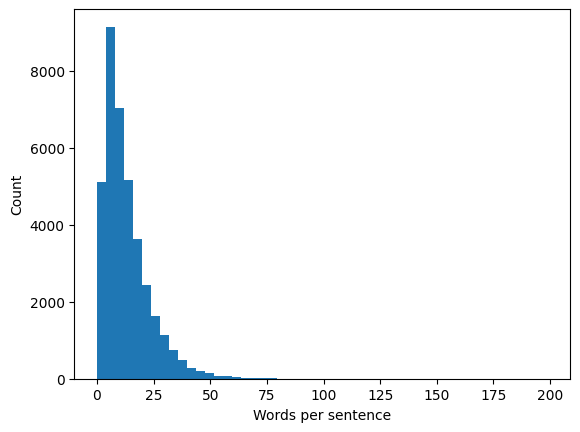

In [2]:
for root, dirs, files in os.walk("data"):
    for file in files:
        print(file)


def load_books(root_folder="data", n=4):
  all_text= []
  count=0
  for root, dirs,files in os.walk (root_folder):
    for file in sorted(files) :# sorts the file so i can get the first 4
      if file.lower().endswith(".txt") and count < n:
        full_path = os.path.join (root, file )
        with open (full_path, "r", encoding="utf-8") as f:# reading the file in standerd text file
          all_text.append(f.read())
        count +=1
        if count >= n:
          break
  return "\n".join(all_text)
raw_text = load_books("data",n=4)
print (f"Total characters loaded :{len (raw_text)}")
print(raw_text[:500])

#total number of charecters in the raw text
print (f"tolal char:{ len(raw_text)}")

words= raw_text.split()
print(f"total words :{len(words)}")

print(f"unique words:{len(set(words))}")

sentences= re.split(r'[.!?]',raw_text)
avg_len= sum(len(s.split()) for s in sentences) / len(sentences)
print(f"average words per sentences:{avg_len:.2f}" )


word_count= Counter(words)
print(word_count.most_common(20))

common_words = word_count.most_common(30)
words, counts = zip(*common_words)
plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.show()

sentence_lengths = [len(s.split()) for s in sentences]
plt.hist(sentence_lengths, bins=50)
plt.xlabel("Words per sentence")
plt.ylabel("Count")
plt.show()



Data Preprocessing 

In [3]:
stop_words= set(stopwords.words('english'))
def clean_text(text):
  text = unicodedata.normalize("NFKC", text)
  text= text.lower()
  text= re.sub(r"[^\w\s]+"," ", text)# keep only letters and numbers
  words= text.split()
  words = [word for word in words if word not in stop_words or len(word)==1]
  text= " ".join(words)
  text = re.sub(r"[^\x00-\x7F]+", " ", text)#remove non ASCII characters
  return text.strip()# remove leading space

cleaned_text= clean_text(raw_text)
print(cleaned_text[:500])

m r mrs dursley number four privet drive proud say perfectly normal thank much last people d expect involved anything strange mysterious t hold nonsense mr dursley director a firm called grunnings made drills a big beefy man hardly neck although a large mustache mrs dursley thin blonde nearly twice usual amount neck came useful spent much time craning garden fences spying neighbors dursleys a small son called dudley opinion finer boy anywhere dursleys everything wanted also a secret greatest fea


Tokenization and Final Data Preview 

In [4]:
max_tokens =20000
seq_length = 120 # Define the consistent sequence length for the model

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    # Removed output_sequence_length to prevent truncating the text during adapt.
    # Sequence length will be handled by dataset_pipeline and pad_sequences.
    standardize=None,
    split="whitespace"
)
vectorizer.adapt([cleaned_text])

def dataset_pipeline( text, vectorizer, seq_length, batch_size=64, shuffle_buffer=10000):
  tokens = vectorizer([text])
  tokens = tf.squeeze(tokens, axis =0)
  ds= tf.data.Dataset.from_tensor_slices(tokens)
  ds= ds.window(seq_length+1 , shift=1, drop_remainder=True)
  ds=ds.flat_map(lambda W:W.batch(seq_length+1))
  ds= ds.map(lambda W :(W[:-1],W[1:]), num_parallel_calls=tf.data.AUTOTUNE)
  ds=ds.shuffle(shuffle_buffer).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
  ds = ds.repeat() # Add .repeat() to make the dataset infinite
  return ds

dataset = dataset_pipeline(
    cleaned_text,
    vectorizer,
    seq_length,
    batch_size=64
)

print("RAW TEXT PREVIEW ")
print(raw_text[:500])

print("CLEANED TEXT PREVIEW ")
print(cleaned_text[:500])

print(f"Raw text length: {len(raw_text)}")
print(f"Cleaned text length: {len(cleaned_text)}")

print(f"Unique chars in raw text: {len(set(raw_text))}")
print(f"Unique chars in cleaned text: {len(set(cleaned_text))}")

removed_chars = len(raw_text) - len(cleaned_text)
print(f"Number of characters removed during cleaning: {removed_chars}")

non_ascii = [c for c in raw_text if ord(c) > 127]
print(f"Number of non-ASCII characters in raw text: {len(non_ascii)}")

RAW TEXT PREVIEW 
M r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in anything strange or mysterious, because they just didn’t hold with such nonsense.

Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amoun
CLEANED TEXT PREVIEW 
m r mrs dursley number four privet drive proud say perfectly normal thank much last people d expect involved anything strange mysterious t hold nonsense mr dursley director a firm called grunnings made drills a big beefy man hardly neck although a large mustache mrs dursley thin blonde nearly twice usual amount neck came useful spent much time craning garden fences spying neighbors dursleys a small son called dudley opinion finer boy anywhere dursleys eve

RNN Model

In [6]:
steps_per_epoch = 100  # number of batches per epoch
vocab_size = vectorizer.vocabulary_size()

rnn_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=256,
        input_shape=(seq_length,)
    ),

    tf.keras.layers.SimpleRNN(512, return_sequences=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.SimpleRNN(512, return_sequences=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(vocab_size)  # No softmax
])

rnn_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()


early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

history = rnn_model.fit(
    dataset,
    steps_per_epoch=50,
    epochs=10,
    callbacks=[early_stop]
)

print("Training loss history:", history.history['loss'])
print("Training accuracy history:", history.history['accuracy'])

c:\Users\arjb0\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 256)       │     3,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 120, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 120, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 120, 512)       │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 120, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120, 14230)     │     7,299,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,865,494 (45.26 MB)

 Trainable params: 11,863,446 (45.26 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 919ms/step - accuracy: 0.3542 - loss: 6.7706
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7791 - loss: 1.8648
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8739 - loss: 1.0575
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8924 - loss: 0.8855
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 999ms/step - accuracy: 0.8956 - loss: 0.8353
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8885 - loss: 0.8854
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8921 - loss: 0.8430
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8921 - loss: 0.8110
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8852 - loss: 0.8544
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8732 - loss: 0.9262
Training loss history: [6.770557403564453, 1.8648185729980469, 1.0574536323547363, 0.8855159878730774, 0.8353080749511719, 0.8854348063468933, 0.84304165

RNN + Attention Model 

In [7]:
from tensorflow.keras.layers import Attention


vocab_size = vectorizer.vocabulary_size()
embedding_dim = 256
rnn_units = 512

inputs = tf.keras.Input(shape=(seq_length,))

# Embedding
x = tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)(inputs)

# First RNN layer
x = tf.keras.layers.SimpleRNN(
    rnn_units,
    return_sequences=True
)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Second RNN layer
x = tf.keras.layers.SimpleRNN(
    rnn_units,
    return_sequences=True
)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Attention layer

attention_output = Attention()([x, x])

# Combine attention with RNN output
x = tf.keras.layers.Concatenate()([x, attention_output])

# Output layer
outputs = tf.keras.layers.Dense(vocab_size)(x)

# Model
rnn_attention_model = tf.keras.Model(inputs=inputs, outputs=outputs)

rnn_attention_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rnn_attention_model.summary()

rnn_attention_model.fit(
    dataset,
    epochs=10,
    steps_per_epoch=50
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 120)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 120, 256)  │  3,642,880 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_2        │ (None, 120, 512)  │    393,728 │ embedding_1[0][0] │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 512)  │      2,048 │ simple_rnn_2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 120, 512)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_3        │ (None, 120, 512)  │    524,800 │ dropout_2[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 512)  │      2,048 │ simple_rnn_3[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 120, 512)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 120, 512)  │          0 │ dropout_3[0][0],  │
│ (Attention)         │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 120, 1024) │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 120,       │ 14,585,750 │ concatenate[0][0] │
│                     │ 14230)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,151,254 (73.06 MB)

 Trainable params: 19,149,206 (73.05 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.4839 - loss: 5.2495
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8623 - loss: 1.0473
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8895 - loss: 0.8536
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8963 - loss: 0.8056
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8967 - loss: 0.7916
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.8965 - loss: 0.7824
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8936 - loss: 0.7713
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.8888 - loss: 0.7845
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8769 - loss: 0.8686
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8808 - loss: 0.8147


In [ ]:
# LSTM Model 
vocab_size = vectorizer.vocabulary_size()
seq_length = 120

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=256, input_shape=(seq_length,)),

    tf.keras.layers.LSTM(512, return_sequences=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(512, return_sequences=True),   
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(vocab_size)  
])

lstm_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


early_stop = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    dataset,
    epochs=20,
    steps_per_epoch=50,
    callbacks=[
        early_stop
    ]
)
print("LSTM loss:", history_lstm.history["loss"])
print("LSTM acc:", history_lstm.history["accuracy"])


c:\Users\arjb0\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.1999 - loss: 6.0559
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.5343 - loss: 2.3532
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.7165 - loss: 1.5789
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.7859 - loss: 1.3313
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.8231 - loss: 1.1472
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.8363 - loss: 1.0894
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.8464 - loss: 1.0226
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.8505 - loss: 0.9713
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8471 - loss: 1.0039
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8467 - loss: 0.9867
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.8423 - loss: 0.9993
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.

: 

GRU Model (with BatchNorm + Dropout)

In [10]:
# Model Architecrture 

vocab_size = vectorizer.vocabulary_size()
embedding_dim = 256
gru_units = 512

gru_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=seq_length
    ),

    tf.keras.layers.GRU(
        gru_units,
        return_sequences=True
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.GRU(
        gru_units,
        return_sequences=True
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(vocab_size)  # logits
])

# Model Compilation



gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Early Stopping Callback

early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

# Model Training

steps_per_epoch = 100  # tune based on dataset size

history = gru_model.fit(
    dataset,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    callbacks=[early_stop]
)

gru_model.summary()

Epoch 1/30


c:\Users\arjb0\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.5544 - loss: 3.6564
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.8580 - loss: 1.0695
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.8694 - loss: 0.9516
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.8679 - loss: 0.9192
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.8604 - loss: 0.9270
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.8504 - loss: 0.9736
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8521 - loss: 0.9658
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8523 - loss: 0.9714
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.8563 - loss: 0.9419


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (64, None, 256)        │     3,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (64, None, 512)        │     1,182,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (64, None, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (64, None, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (64, None, 512)        │     1,575,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (64, None, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (64, None, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, None, 14230)      │     7,299,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,112,772 (156.83 MB)

 Trainable params: 13,703,574 (52.27 MB)

 Non-trainable params: 2,048 (8.00 KB)

 Optimizer params: 27,407,150 (104.55 MB)

In [ ]:
import os, json
os.makedirs("artifacts", exist_ok=True)

rnn_model.save("artifacts/rnn.keras")
lstm_model.save("artifacts/lstm.keras")
gru_model.save("artifacts/gru.keras")

vec_config = vectorizer.get_config()
vec_vocab  = vectorizer.get_vocabulary()

with open("artifacts/vectorizer_config.json", "w", encoding="utf-8") as f:
    json.dump(vec_config, f, ensure_ascii=False, indent=2)

with open("artifacts/vocab.txt", "w", encoding="utf-8") as f:
    for token in vec_vocab:
        f.write(token + "\n")

meta = {"seq_length": int(seq_length)}
with open("artifacts/meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print(" Saved artifacts/ successfully")


✅ Saved artifacts/ successfully
